# Analysis of all Models
### Import all Models

In [11]:
from Naive_Methods.Frangi import infer_frangi
from Naive_Methods.Otsu_CLAHE import infer_otsu_clahe
from Naive_Methods.Threshold import infer_naive_threshold
from SegFormer.SegFormer_Model import inference_SegFormer
from U_Net.U_Net_Model import inference_unet

### Load Database

In [12]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import os
import time
from PIL import Image
import torch
import numpy as np

In [13]:
from transformers import SegformerImageProcessor
class PavementDataset(Dataset):
    def __init__(self, root, list_txt):
        self.root = root
        self.samples = []

        with open(list_txt, "r") as f:
            for line in f:
                img, mask = line.strip().split()
                self.samples.append((img, mask))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        image = Image.open(os.path.join(self.root, img_path)).convert("RGB")
        mask = Image.open(os.path.join(self.root, mask_path)).convert("L")

        mask = np.array(mask)
        mask = (mask > 0).astype(np.int64)  # binary clean

        return image, mask


def collate_fn(batch, processor):
    images = [item[0] for item in batch]
    masks  = [item[1] for item in batch]

    inputs = processor(
        images=images,
        segmentation_maps=masks,
        return_tensors="pt"
    )

    return inputs
class PavementDatasetNaive(Dataset):
    def __init__(self, dataset_root, list_txt):
        self.dataset_root = dataset_root
        self.transform = None
        self.pairs = []

        with open(list_txt, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    img_path = os.path.join(dataset_root, parts[0])
                    mask_path = os.path.join(dataset_root, parts[1])
                    self.pairs.append((img_path, mask_path))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, index):
        img_path, mask_path = self.pairs[index]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
        
        return image, mask

test_ds = PavementDataset("./CRACK500", "./CRACK500/test.txt")
test_nds = PavementDatasetNaive("./CRACK500", "./CRACK500/test.txt")
checkpoint = "nvidia/mit-b0"
processor = SegformerImageProcessor.from_pretrained(checkpoint)
test_loader = DataLoader(
    test_ds,
    batch_size=4,
    collate_fn=lambda x: collate_fn(x, processor)
)

### Test All Functions

### Naive Thresholding

In [14]:
test_metrics = {'tp': 0, 'tn': 0, 'fp': 0, 'fn': 0, 'loss': 0.0}
start_time = time.perf_counter()

for image, mask in test_nds:
    preds = infer_naive_threshold(image)
    mask_np = (np.array(mask) > 127).astype(np.uint8)

    test_metrics['tp'] += np.sum((preds == 1) & (mask_np == 1))
    test_metrics['tn'] += np.sum((preds == 0) & (mask_np == 0))
    test_metrics['fp'] += np.sum((preds == 1) & (mask_np == 0))
    test_metrics['fn'] += np.sum((preds == 0) & (mask_np == 1))

# --- After the loop ---

def calc_stats(m, dataset_len):
    total_px = m['tp'] + m['tn'] + m['fp'] + m['fn']
    acc = (m['tp'] + m['tn']) / (total_px + 1e-9)
    prec = m['tp'] / (m['tp'] + m['fp'] + 1e-9)
    rec = m['tp'] / (m['tp'] + m['fn'] + 1e-9)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
    return acc, prec, rec, f1

te_acc, te_prec, te_rec, te_f1 = calc_stats(test_metrics, len(test_nds))

print("--- Results ---")
print(f"Test Acc: {te_acc:.5f}\nTest Prec: {te_prec:.5f}\nTest Rec: {te_rec:.5f}\nTest F1: {te_f1:.5f}")

end_time = time.perf_counter()
total_time = end_time - start_time
num_images = len(test_nds)
print(f"Total Time: {total_time:.2f}s\nAverage Time: {total_time/num_images:.4f}s\nThroughput: {num_images/total_time:.2f} img/s")

--- Results ---
Test Acc: 0.93892
Test Prec: 0.41371
Test Rec: 0.22200
Test F1: 0.28895
Total Time: 2.04s
Average Time: 0.0018s
Throughput: 550.63 img/s


Otsu + CLAHE

In [15]:
test_metrics = {'tp': 0, 'tn': 0, 'fp': 0, 'fn': 0, 'loss': 0.0}
start_time = time.perf_counter()

for image, mask in test_nds:
    preds = infer_otsu_clahe(image)
    mask_np = (np.array(mask) > 127).astype(np.uint8)

    test_metrics['tp'] += np.sum((preds == 1) & (mask_np == 1))
    test_metrics['tn'] += np.sum((preds == 0) & (mask_np == 0))
    test_metrics['fp'] += np.sum((preds == 1) & (mask_np == 0))
    test_metrics['fn'] += np.sum((preds == 0) & (mask_np == 1))

# --- After the loop ---

def calc_stats(m, dataset_len):
    total_px = m['tp'] + m['tn'] + m['fp'] + m['fn']
    acc = (m['tp'] + m['tn']) / (total_px + 1e-9)
    prec = m['tp'] / (m['tp'] + m['fp'] + 1e-9)
    rec = m['tp'] / (m['tp'] + m['fn'] + 1e-9)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
    return acc, prec, rec, f1

te_acc, te_prec, te_rec, te_f1 = calc_stats(test_metrics, len(test_nds))

print("--- Results ---")
print(f"Test Acc: {te_acc:.5f}\nTest Prec: {te_prec:.5f}\nTest Rec: {te_rec:.5f}\nTest F1: {te_f1:.5f}")

end_time = time.perf_counter()
total_time = end_time - start_time
num_images = len(test_nds)
print(f"Total Time: {total_time:.2f}s\nAverage Time: {total_time/num_images:.4f}s\nThroughput: {num_images/total_time:.2f} img/s")

--- Results ---
Test Acc: 0.93704
Test Prec: 0.41009
Test Rec: 0.28774
Test F1: 0.33819
Total Time: 35.35s
Average Time: 0.0314s
Throughput: 31.80 img/s


### Frangi

In [16]:
from Frangi_Filter_Pavement_Cracking.soft_frangi_filter2d import SoftFrangiFilter2D
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SIGMAS       = [4, 5, 6, 7, 8]
PERCENTILE   = 92
ALPHA        = 1
BETA         = .8
frangi_filter = SoftFrangiFilter2D(1, 13, SIGMAS, ALPHA, BETA, DEVICE)

/home/vytas/Desktop/Personal Projects/CEE498ML/.venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [17]:
test_metrics = {'tp': 0, 'tn': 0, 'fp': 0, 'fn': 0, 'loss': 0.0}
start_time = time.perf_counter()

for image, mask in test_nds:
    preds = infer_frangi(image, frangi_filter=frangi_filter, device=DEVICE)
    mask_np = (np.array(mask) > 127).astype(np.uint8)

    test_metrics['tp'] += np.sum((preds == 1) & (mask_np == 1))
    test_metrics['tn'] += np.sum((preds == 0) & (mask_np == 0))
    test_metrics['fp'] += np.sum((preds == 1) & (mask_np == 0))
    test_metrics['fn'] += np.sum((preds == 0) & (mask_np == 1))

# --- After the loop ---

def calc_stats(m, dataset_len):
    total_px = m['tp'] + m['tn'] + m['fp'] + m['fn']
    acc = (m['tp'] + m['tn']) / (total_px + 1e-9)
    prec = m['tp'] / (m['tp'] + m['fp'] + 1e-9)
    rec = m['tp'] / (m['tp'] + m['fn'] + 1e-9)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
    return acc, prec, rec, f1

te_acc, te_prec, te_rec, te_f1 = calc_stats(test_metrics, len(test_nds))

print("--- Results ---")
print(f"Test Acc: {te_acc:.5f}\nTest Prec: {te_prec:.5f}\nTest Rec: {te_rec:.5f}\nTest F1: {te_f1:.5f}")

end_time = time.perf_counter()
total_time = end_time - start_time
num_images = len(test_nds)
print(f"Total Time: {total_time:.2f}s\nAverage Time: {total_time/num_images:.4f}s\nThroughput: {num_images/total_time:.2f} img/s")

--- Results ---
Test Acc: 0.92981
Test Prec: 0.40789
Test Rec: 0.56592
Test F1: 0.47408
Total Time: 104.87s
Average Time: 0.0933s
Throughput: 10.72 img/s


### U-Net

In [18]:
import torch
import numpy as np
import time
from PIL import Image
from U_Net.U_Net_Model import UNet

# 1. Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = './U_Net/checkpoints/Early_Stop/best_unet_model.pth'
model = UNet(in_channels=3).to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint)
model.eval()

test_metrics = {'tp': 0, 'tn': 0, 'fp': 0, 'fn': 0}
start_time = time.perf_counter()

with torch.no_grad():
    # 3. Use the Dataset (test_nds) to get PIL images directly
    for image, mask in test_nds:
        
        # 4. Run your inference function 
        # (Assuming it returns a 2D numpy array of 0s and 1s)
        preds = inference_unet(model, image, device=device) 
        
        # 5. Resize mask to match prediction (PIL uses W, H)
        # We use NEAREST to keep the mask binary (no blurry edges)
        h, w = preds.shape
        mask_resized = mask.resize((w, h), Image.NEAREST)
        mask_np = (np.array(mask_resized) > 127).astype(np.uint8)

        # 6. Accumulate metrics using NumPy
        test_metrics['tp'] += np.sum((preds == 1) & (mask_np == 1))
        test_metrics['tn'] += np.sum((preds == 0) & (mask_np == 0))
        test_metrics['fp'] += np.sum((preds == 1) & (mask_np == 0))
        test_metrics['fn'] += np.sum((preds == 0) & (mask_np == 1))

def calc_stats(m, dataset_len):
    total_px = m['tp'] + m['tn'] + m['fp'] + m['fn']
    acc = (m['tp'] + m['tn']) / (total_px + 1e-9)
    prec = m['tp'] / (m['tp'] + m['fp'] + 1e-9)
    rec = m['tp'] / (m['tp'] + m['fn'] + 1e-9)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
    return acc, prec, rec, f1

te_acc, te_prec, te_rec, te_f1 = calc_stats(test_metrics, len(test_nds))

print("--- Results ---")
print(f"Test Acc: {te_acc:.5f}\nTest Prec: {te_prec:.5f}\nTest Rec: {te_rec:.5f}\nTest F1: {te_f1:.5f}")

end_time = time.perf_counter()
total_time = end_time - start_time
num_images = len(test_nds)
print(f"Total Time: {total_time:.2f}s\nAverage Time: {total_time/num_images:.4f}s\nThroughput: {num_images/total_time:.2f} img/s")

KeyboardInterrupt: 

### SegFormer

In [19]:
from transformers import SegformerImageProcessor
from transformers import SegformerForSemanticSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = './SegFormer/results/best_model'
processor = SegformerImageProcessor.from_pretrained(MODEL_DIR)
model = SegformerForSemanticSegmentation.from_pretrained(MODEL_DIR).to(device)
model.eval()

test_metrics = {'tp': 0, 'tn': 0, 'fp': 0, 'fn': 0}
start_time = time.perf_counter()

for inputs in test_loader:
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
    labels = inputs["labels"].cpu()
    upsampled = torch.nn.functional.interpolate(outputs.logits, size=labels.shape[-2:], mode="bilinear", align_corners=False)
    preds = upsampled.argmax(dim=1).detach().cpu()
    
    test_metrics['tp'] += torch.sum((preds == 1) & (labels == 1))
    test_metrics['tn'] += torch.sum((preds == 0) & (labels == 0))
    test_metrics['fp'] += torch.sum((preds == 1) & (labels == 0))
    test_metrics['fn'] += torch.sum((preds == 0) & (labels == 1))

def calc_stats(m, dataset_len):
    total_px = m['tp'] + m['tn'] + m['fp'] + m['fn']
    acc = (m['tp'] + m['tn']) / (total_px + 1e-9)
    prec = m['tp'] / (m['tp'] + m['fp'] + 1e-9)
    rec = m['tp'] / (m['tp'] + m['fn'] + 1e-9)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
    return acc, prec, rec, f1

te_acc, te_prec, te_rec, te_f1 = calc_stats(test_metrics, len(test_nds))

print("--- Results ---")
print(f"Test Acc: {te_acc:.5f}\nTest Prec: {te_prec:.5f}\nTest Rec: {te_rec:.5f}\nTest F1: {te_f1:.5f}")

end_time = time.perf_counter()
total_time = end_time - start_time
num_images = len(test_nds)
print(f"Total Time: {total_time:.2f}s\nAverage Time: {total_time/num_images:.4f}s\nThroughput: {num_images/total_time:.2f} img/s")

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 11564.82it/s]


KeyboardInterrupt: 

# Figures for Model Comparision

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 12136.77it/s]


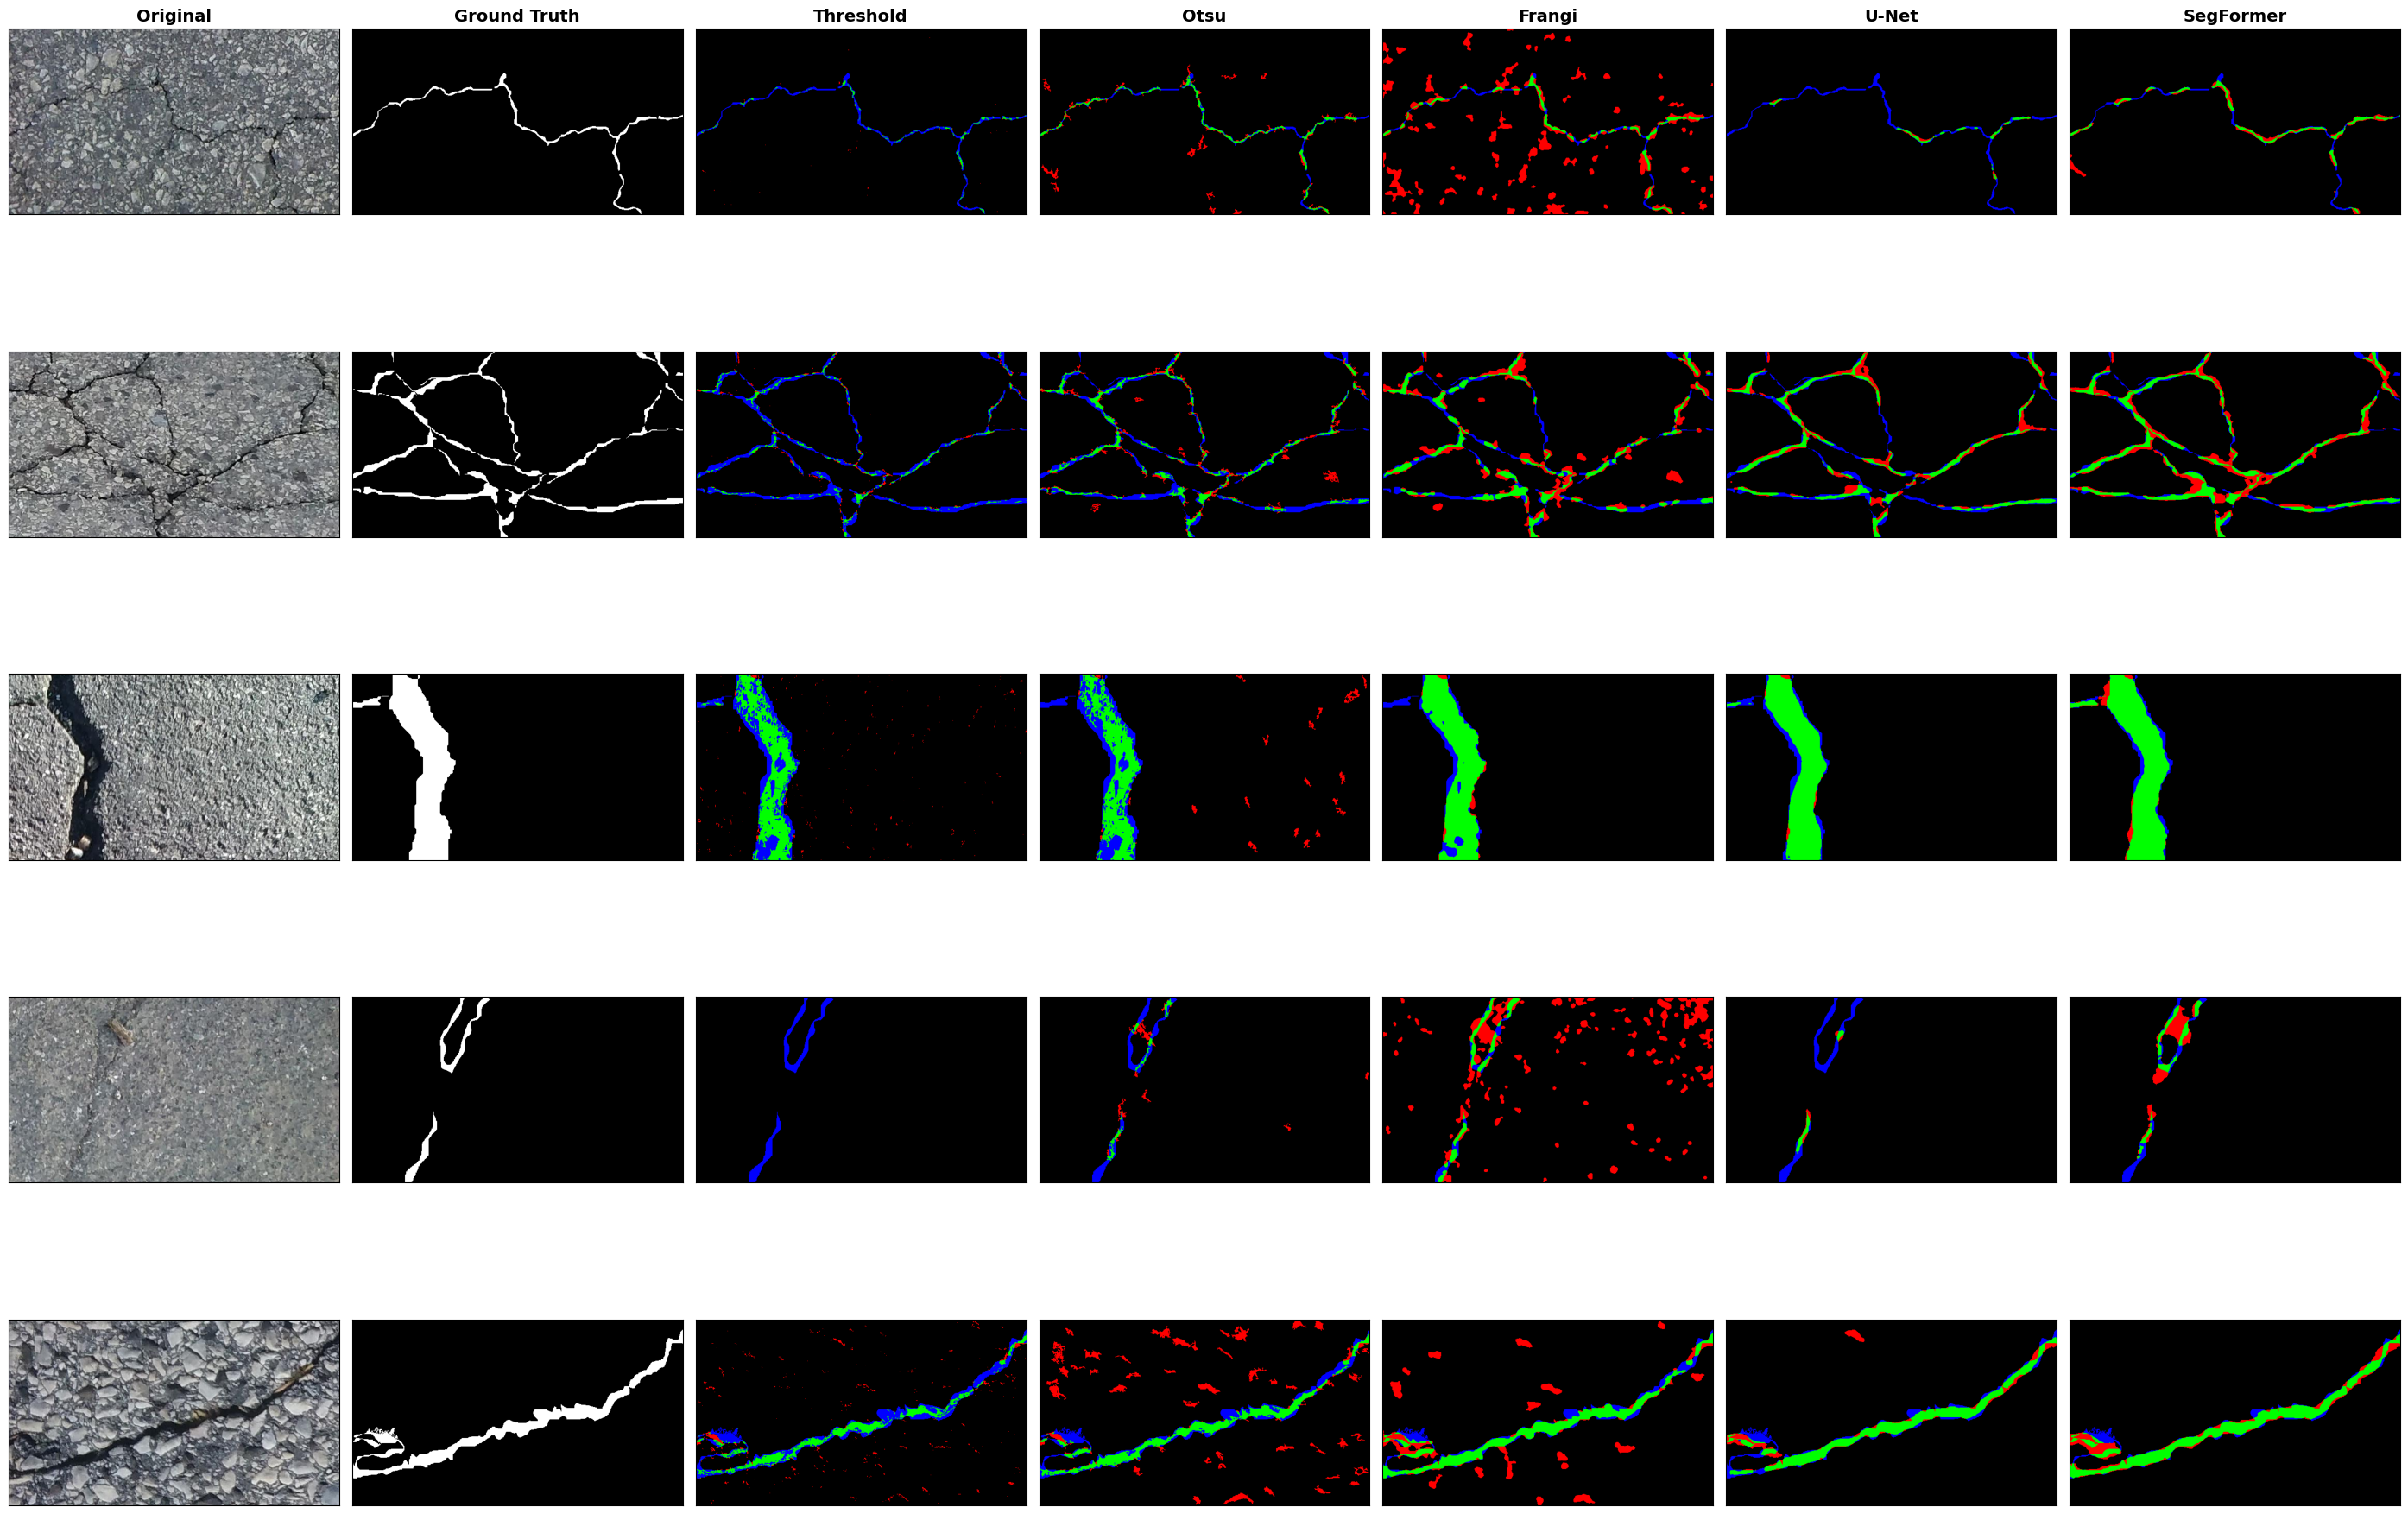

In [28]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Assuming you have paths to your images
image_paths = [
    './CRACK500/testcrop/20160222_114759_1_1081.jpg',
    './CRACK500/testcrop/20160222_164141_1281_361.jpg',
    './CRACK500/testcrop/20160308_155731_1281_1.jpg',
    './CRACK500/testcrop/20160307_164214_1921_1.jpg',
    './CRACK500/testcrop/20160329_104111_1_361.jpg',
]
gt_paths = [
    './CRACK500/testcrop/20160222_114759_1_1081.png',
    './CRACK500/testcrop/20160222_164141_1281_361.png',
    './CRACK500/testcrop/20160308_155731_1281_1.png',
    './CRACK500/testcrop/20160307_164214_1921_1.png',
    './CRACK500/testcrop/20160329_104111_1_361.png',
]

# Load using PIL and convert to Numpy for processing
test_images = [(Image.open(p).convert("RGB")) for p in image_paths]
ground_truths = [np.array(Image.open(p).convert("L")) for p in gt_paths]

def create_comparison_plot(original_imgs, ground_truths, predictions, method_names):
    num_images = len(original_imgs)
    num_methods = len(method_names) + 2  # Original + GT + Models
    
    fig, axes = plt.subplots(num_images, num_methods, figsize=(4 * num_methods, 4 * num_images))
    
    headers = ["Original", "Ground Truth"] + method_names

    for i in range(num_images):
        # --- Column 1: Original Image ---
        axes[i, 0].imshow(original_imgs[i])
        if i == 0: axes[i, 0].set_title(headers[0], fontsize=14, fontweight='bold')
        
        # --- Column 2: Ground Truth ---
        axes[i, 1].imshow(ground_truths[i], cmap='gray')
        if i == 0: axes[i, 1].set_title(headers[1], fontsize=14, fontweight='bold')

        # --- Column 3+: Method Predictions ---
        for j, method in enumerate(method_names):
            pred = predictions[method][i]
            gt = ground_truths[i]

            # Ensure binary masks (True/False)
            pred_bin = (pred > 0) 
            gt_bin = (gt > 127)

            # Create a black RGB canvas using PIL/Numpy logic
            h, w = pred_bin.shape[:2]
            vis = np.zeros((h, w, 3), dtype=np.uint8)

            # Define logical overlaps
            tp = pred_bin & gt_bin        # Predicted Yes, Actually Yes (Green)
            fp = pred_bin & (~gt_bin)     # Predicted Yes, Actually No (Red)
            fn = (~pred_bin) & gt_bin

            vis[tp] = [0, 255, 0]  # Green
            vis[fp] = [255, 0, 0]  # Red
            vis[fn] = [0, 0, 255]

            axes[i, j+2].imshow(vis)
            if i == 0: axes[i, j+2].set_title(method, fontsize=14, fontweight='bold')

        # Formatting: Remove ticks
        for ax in axes[i]:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()
    # Generate predictions
# Note: You may need to ensure your inference functions return 2D numpy arrays
MODEL_DIR = './SegFormer/results/best_model'
processor = SegformerImageProcessor.from_pretrained(MODEL_DIR)
model = SegformerForSemanticSegmentation.from_pretrained(MODEL_DIR).to(device)
model.eval()

UMODEL_PATH = './U_Net/checkpoints/Early_Stop/best_unet_model.pth'
Umodel = UNet(in_channels=3).to(device)
Ucheckpoint = torch.load(UMODEL_PATH, map_location=device)
Umodel.load_state_dict(Ucheckpoint)
Umodel.eval()
results = {
    "Frangi": [infer_frangi(img, frangi_filter, 'cuda') for img in test_images],
    "Otsu": [infer_otsu_clahe(img) for img in test_images],
    "Threshold": [infer_naive_threshold(img) for img in test_images],
    "SegFormer": [inference_SegFormer(model,processor,img,'cuda') for img in test_images],
    "U-Net": [inference_unet(Umodel, img, 'cuda') for img in test_images]
}

# Run the visualizer
create_comparison_plot(
    test_images, 
    ground_truths, 
    results, 
    ["Threshold", "Otsu", "Frangi", "U-Net", "SegFormer"]
)